# Mini Project: Classification Algorithms Exploration
## Algorithm: Gradient Boosting / XGBoost

**Group members:** Raghad Alharbi, Maram Alzahrani, Turki Abuhaimed, Mohammed Alshatri

**Dataset:** [Kaggle](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)

---

## 1. Introduction

This project adresses a binary classification problem :

predict weather a patient has cardiovascular disease (cardio = 0 or 1) based on health indicators :    

- age
- blood pressure
- cholestrol
- glucose level
- life style habit

This database is a realistic , moderately large dataset with 70,000 patient records with a binary target and a mix of numerical and categorical features, this makes it suited for exploring how Gradient Boosting/XGBoost algorithms preforms on a real world health data.


## 2. Algorithm Explanation: Gradient Boosting / XGBoost


### What is the algorithm?

- **Gradient Boosting** builds a strong model by combining many small decision trees , one after another. Each new tree is traind to fix the mistakes of the trees before it

- **XGBoost** is just a faster , more optimized version of the same idea with extra feature to prevent overfitting.

### How does it work?



1.   Start with a simple prediction
2.   Look at the erros , and how far off the current predictions are
3.   Train new tree to predict those errors
4.  Add new tree's predictions to the model, scaled down by a learning rate
5.  Repeat for many trees , each one shrinking the remaining error a bit more  



### When should this algorithm be used?

- This algorithm is best for structured  or tabular data where you want high accuracy and the relationships between featuers and the target is not a linear.



### Advantages

- Usually very accurate on tabular data
- Handles complex, non-linear patterns well
- No need for feature scaling
- Built-in regularization reduces overfitting

###Limitations


- Can overfit if not tuned properly
- Slower to train than simpler models
- Harder to interpret than a single decision tree
- Sensitive to hyperparameter choices

**Note: Gradient Boosting is the general technique, and XGBoost is a specific, optimized implementation of it. This project explores how  XGBoost applies the same core Gradient Boosting process with added performance and regularization improvements.**

---



## 3. Dataset Exploration (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set(style='whitegrid')

In [ ]:
!pip install -q kagglehub[pandas-datasets]

In [ ]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'sulianova/cardiovascular-disease-dataset',
    'cardio_train.csv',
    pandas_kwargs={'sep': ';'}
)

df.head()

Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.shape

(70000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df['cardio'].value_counts()

,count
cardio,
0,35021
1,34979


- this data has a 70,000 record with a 13 feature
- no missing values
- the target 'cardio' is well balanced
- there are an impossible values in 'ap_hi' and 'ap_lo'that includes negative numbers
- age is stored in days rather in years , hard to read

---

### Visualizations

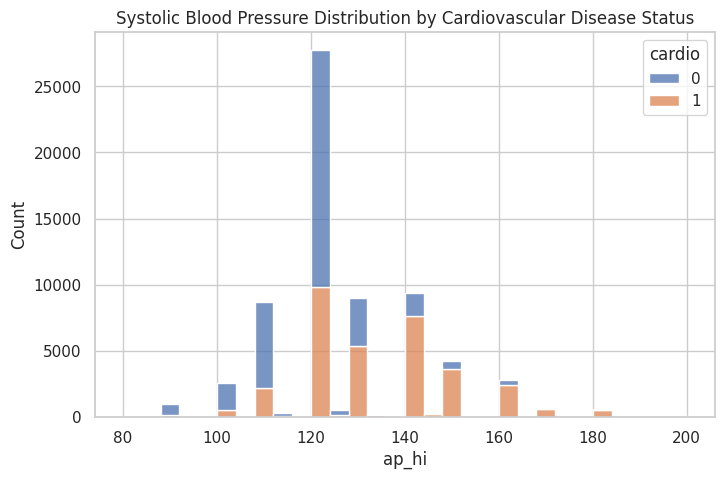

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df[(df['ap_hi'].between(80, 200)) & (df['ap_lo'].between(40, 130))],
             x='ap_hi', hue='cardio', bins=30, multiple='stack')
plt.title('Systolic Blood Pressure Distribution by Cardiovascular Disease Status')
plt.show()

- At normal readings (~120): most patients don't have cardiovascular disease

- As systolic blood pressure rises, the proportion with disease increases steadily

- By 140+, disease cases become roughly equal to or greater than non-disease cases
- Confirms blood pressure as a strong predictor for this classification task

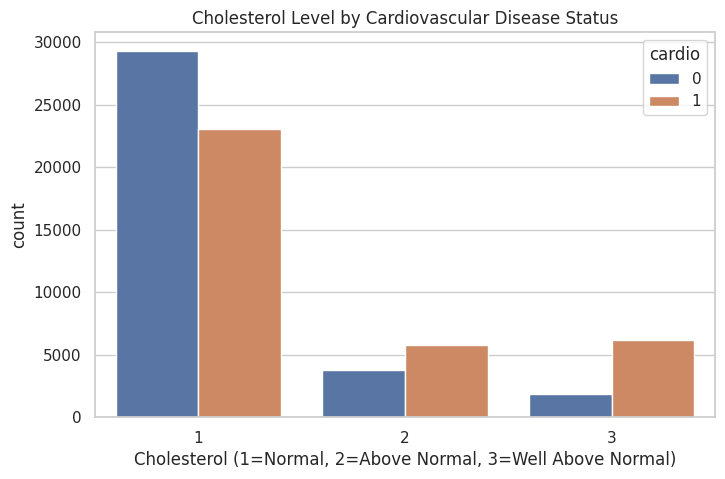

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cholesterol', hue='cardio')
plt.title('Cholesterol Level by Cardiovascular Disease Status')
plt.xlabel('Cholesterol (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.show()

- At normal cholesterol (1): non-disease cases are still the majority, but the gap is smaller than expected

- At above-normal (2) and   well-above-normal (3):
 disease cases clearly outnumber
 non-disease cases
- Clear positive relationship: higher cholesterol -> higher proportion of cardiovascular disease

- Confirms cholesterol as a strong predictor for this classification task

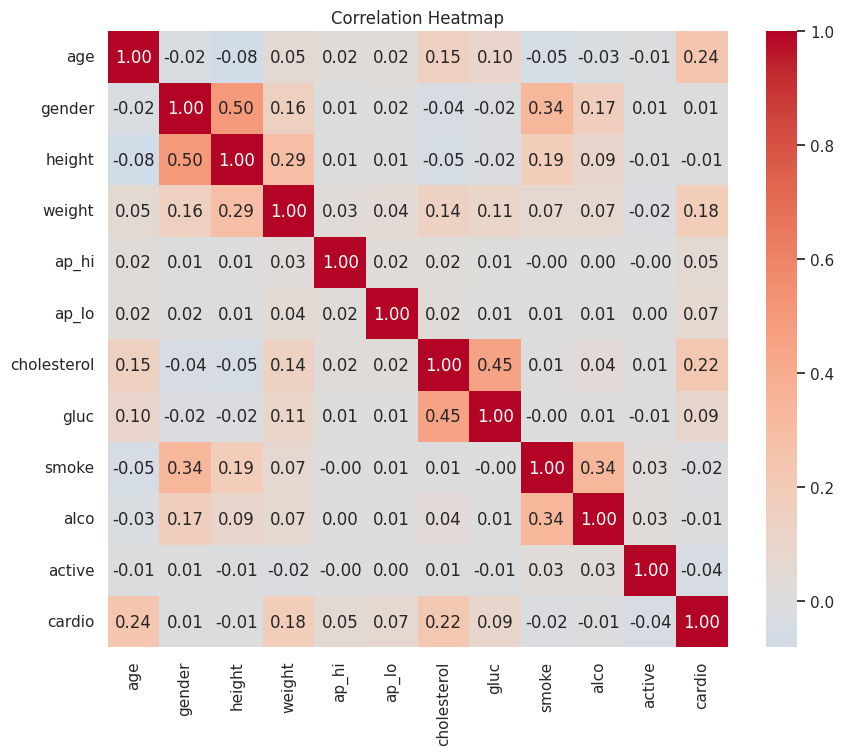

In [ ]:
plt.figure(figsize=(10,8))
corr = df.drop(columns=['id']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

- 'age', 'cholesterol', and 'weight' show the strongest linear correlation with cardio

- 'ap_hi' and 'ap_lo' show surprisingly weak correlation here, despite showing a clear visual relationship in the histogram

- 'cholesterol' and 'gluc' are moderately correlated with each other  

- Lifestyle factors (smoke, alco, active) show almost no correlation with cardio in this dataset

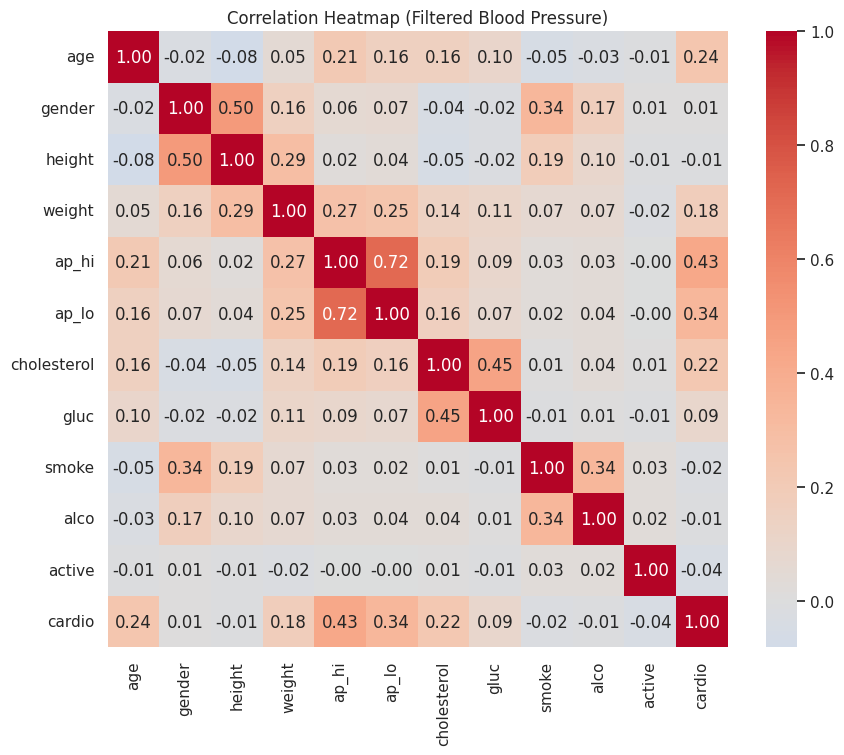

In [ ]:
#recalculating  the correlation heatmap,
#filtering out the impossible values

plt.figure(figsize=(10,8))
corr_filtered = df[(df['ap_hi'].between(80, 200)) & (df['ap_lo'].between(40, 130))].drop(columns=['id']).corr()
sns.heatmap(corr_filtered, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Filtered Blood Pressure)')
plt.show()

- Blood pressure is actually one of the strongest predictors of cardiovascular disease, but this only becomes visible after excluding physiologically impossible outlier values — the raw data's correlation was misleadingly close to zero

- Age and cholesterol are also meaningful predictors

- ap_hi and ap_lo are strongly correlated with each other, as expected since systolic and diastolic pressure move together

- Lifestyle habits (smoking, alcohol, activity) show weak correlation with disease in this dataset

## 4. Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.dtypes

,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In [ ]:
# Handle missing values
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
# Handling duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# id is just a row identifier and is dropped
df_clean = df.drop(columns=['id']).copy()

In [ ]:
# age is given in days, convert it to years
df_clean['age_years'] = (df_clean['age'] / 365).round().astype(int)
df_clean = df_clean.drop(columns=['age'])

In [ ]:
'''
 ap_hi (systolic BP) and ap_lo (diastolic BP) contain impossible values
 (negative numbers, values in the thousands, and rows where diastolic > systolic,
 which is not physiologically possible), so filter these to clinically plausible ranges
 '''
df_clean = df_clean[(df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 250)]
df_clean = df_clean[(df_clean['ap_lo'] >= 40) & (df_clean['ap_lo'] <= 200)]
df_clean = df_clean[df_clean['ap_hi'] >= df_clean['ap_lo']]

In [ ]:
'''
height and weight contain a small number of extreme outliers
such as 250cm height and 10kg weight, so clip these using the 1st-99th percentile.
'''
for col in ['height', 'weight']:
    lower, upper = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

In [ ]:
# There is no encoding for the categorical variables required, since all are numeric

In [ ]:
print('Rows before cleaning:', df.shape[0])
print('Rows after cleaning :', df_clean.shape[0])
print('Rows removed        :', df.shape[0] - df_clean.shape[0])

Rows before cleaning: 70000
Rows after cleaning : 66212
Rows removed        : 3788


- Feature scaling is not required for GBoost/XGBoost, since it is a tree-based model that splits data using threshold values rather than distance calculations, making it insensitive to the scale of the features.

In [ ]:
# Data splitting
X = df_clean.drop(columns=['cardio'])
y = df_clean['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (52969, 11)  Test shape: (13243, 11)


## 5. Model Training

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

The XGBoost model was successfully trained using the training dataset. During this step, the model learned the relationship between the health features and the target variable (cardio).

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

The Gradient Boosting model was trained using the same training data so that its performance could be compared fairly with XGBoost.

## 6. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    'Precision': [
        precision_score(y_test, gb_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, gb_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, gb_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.735634,0.753374,0.691073,0.72088
1,XGBoost,0.730650,0.748621,0.684653,0.71521


The two models were evaluated using Accuracy, Precision, Recall, and F1 Score. The results help us identify which model performs better in predicting cardiovascular disease.

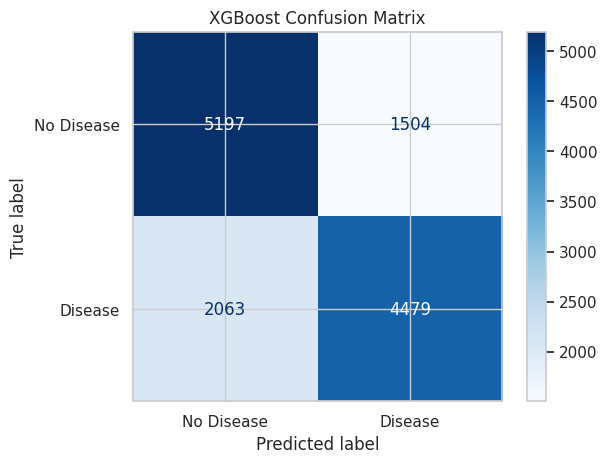

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['No Disease', 'Disease']
)

disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

The XGBoost confusion matrix shows how many patients were classified correctly and incorrectly. Most predictions were correct, but the model still produced some false positives and false negatives.

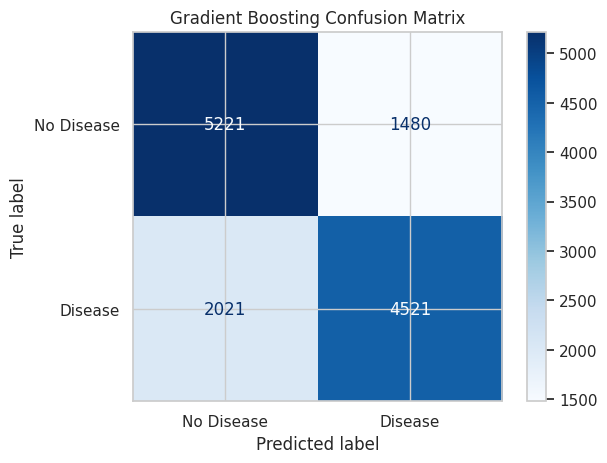

In [ ]:
cm_gb = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=['No Disease', 'Disease']
)

disp.plot(cmap='Blues')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

The Gradient Boosting confusion matrix also shows the correct and incorrect predictions. Comparing both confusion matrices helps us see which model makes fewer classification errors.

Based on the evaluation results, Gradient Boosting performed better overall because it achieved higher evaluation scores and made fewer incorrect predictions.

## Bonus: compare against another model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)

Accuracy: 0.7286868534320018
Precision: 0.7570158619487537
Recall: 0.6638642616936716
F1 Score: 0.7073865949995928


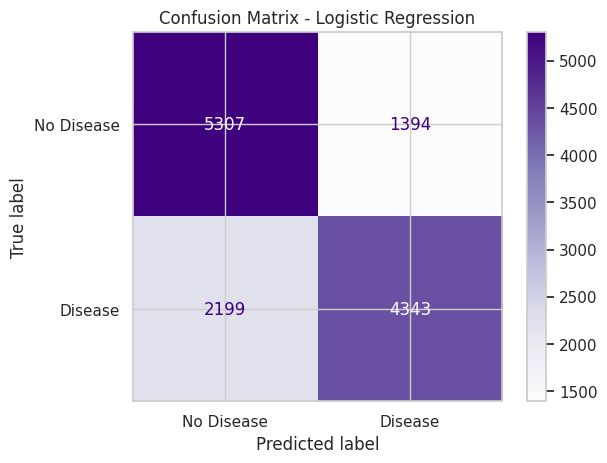

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['No Disease', 'Disease']
)

disp_lr.plot(cmap='Purples')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Logistic Regression'],

    'Accuracy': [
        accuracy_score(y_test, xgb_pred),
        accuracy_lr
    ],

    'Precision': [
        precision_score(y_test, xgb_pred),
        precision_lr
    ],

    'Recall': [
        recall_score(y_test, xgb_pred),
        recall_lr
    ],

    'F1 Score': [
        f1_score(y_test, xgb_pred),
        f1_lr
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.730650,0.748621,0.684653,0.715210
1,Logistic Regression,0.728687,0.757016,0.663864,0.707387


XGBoost slightly outperformed Logistic Regression across every metric (Accuracy: ~73.1% vs ~72.9%, F1: ~71.5% vs ~70.7%).

## 7. Key insights

**Overall performance:** The XGBoost model achieved 73.1% accuracy, 74.9% precision, 68.5% recall, and a 71.5% F1-score on the held-out test set of 13,243 patients. This is a solid result for a binary health classification task.

**Where the model struggled:** The gap between precision (74.9%) and recall (68.5%) shows the model is more conservative about predicting disease — it produces more false negatives (patients with disease who were missed) than false positives. In a medical screening context this matters: missing an at-risk patient is usually more costly than a false alarm, so a real deployment of this model might lower the classification threshold to prioritize recall over precision.

**Comparison with Logistic Regression:** As shown in the Bonus section above, XGBoost slightly outperformed Logistic Regression (73.1% vs 72.9% accuracy). The margin is modest rather than dramatic, but it is consistent across every metric, showing that the added model complexity is genuinely paying off on a dataset of this size (66,212 cleaned records).